In [15]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

# Load the MUSE from the emiles library

In [16]:
muse_emiles = fits.open('/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/ppxf_muse/emiles_ppxf_muse/c30_DATACUBE_normppxf_skycont_Part1_0000_ppxf_products_emiles.fits')

In [17]:
muse_emiles.info()

Filename: /Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/ppxf_muse/emiles_ppxf_muse/c30_DATACUBE_normppxf_skycont_Part1_0000_ppxf_products_emiles.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      22   ()      
  1  BIN_RESULTS    1 BinTableHDU     47   2180R x 19C   [J, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, J, D, D]   
  2  SPAXELS       1 BinTableHDU     43   90000R x 17C   [J, J, D, D, D, D, J, D, D, D, D, D, D, D, D, D, D]   
  3  BIN_MAP       1 ImageHDU         8   (300, 300)   int32   
  4  VEL_MAP       1 ImageHDU         8   (300, 300)   float32   
  5  SIGMA_MAP     1 ImageHDU         8   (300, 300)   float32   
  6  H3_MAP        1 ImageHDU         8   (300, 300)   float32   
  7  H4_MAP        1 ImageHDU         8   (300, 300)   float32   
  8  VELERR_MAP    1 ImageHDU         8   (300, 300)   float32   
  9  SIGERR_MAP    1 ImageHDU         8   (300, 300)   float32   
 10  H3ERR_MAP     1 ImageHDU        

In [18]:
# plot the sigma map
    
def plot_map(x, y, values, cmap='RdBu_r', cbar_label='Value',
              ax=None, show=True, vmin=None, vmax=None, cbar=True):
    # takes the xy and values and plots as an image with a colorbar
    # create a grid of x and y values
    xi = np.linspace(np.min(x), np.max(x), 100)
    yi = np.linspace(np.min(y), np.max(y), 100)
    xi, yi = np.meshgrid(xi, yi)
    # interpolate the values onto the grid
    zi = griddata((x, y), values, (xi, yi), method='cubic')
    # plot the image
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))
    im = ax.imshow(zi, extent=(np.min(x), np.max(x), np.min(y), np.max(y)),
                    origin='lower', cmap=cmap, vmin=vmin, vmax=vmax)
    if cbar:
        plt.colorbar(im, ax=ax, label=cbar_label, pad=0.01)
    ax.set_xlabel('X (arcsec)')
    ax.set_ylabel('Y (arcsec)')
    if show:
        plt.show()

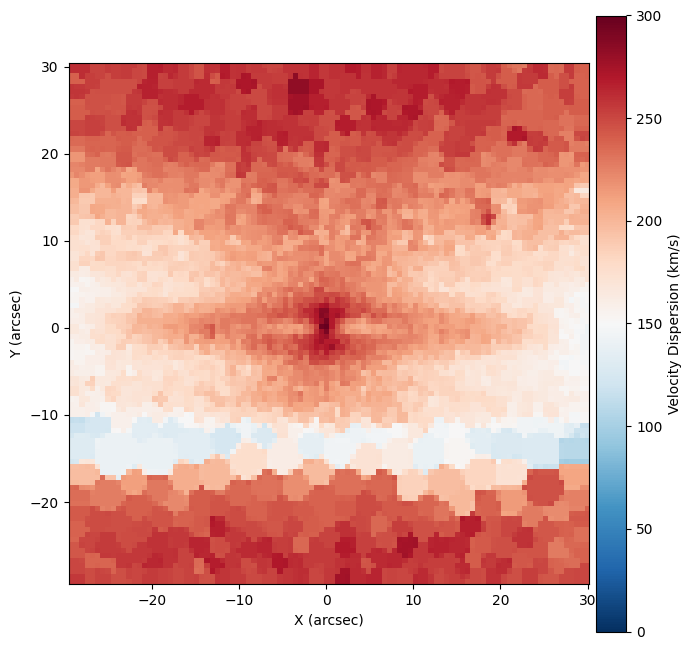

In [19]:
plot_map(muse_emiles[2].data['X_ARCSEC'], muse_emiles[2].data['Y_ARCSEC'], muse_emiles[2].data['SIGMA_KMS'], cmap='RdBu_r', cbar_label='Velocity Dispersion (km/s)', vmin=0, vmax=300)

# Lets load the F90 - F200 colormap

In [20]:
dmag = fits.open('/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/dust_mask/dmag.fits')

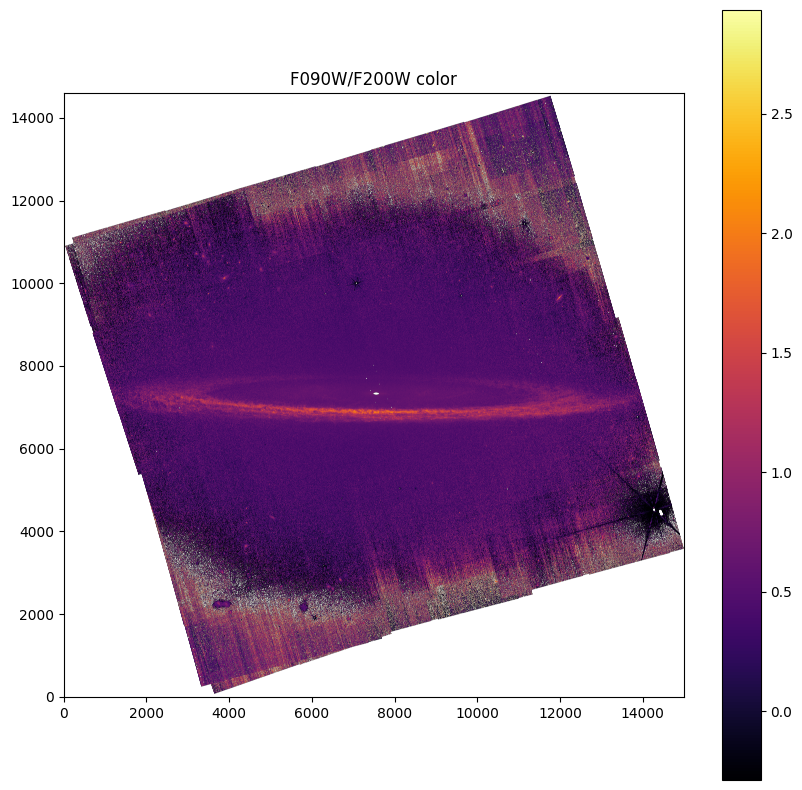

In [21]:
fig, ax = plt.subplots(figsize=(10, 10))
cb = ax.imshow(dmag[1].data, origin="lower", cmap="inferno",
            vmin=np.nanpercentile(dmag[1].data, 5), vmax=np.nanpercentile(dmag[1].data, 99.5))
plt.colorbar(cb, ax=ax)
ax.set_title("F090W/F200W color")
plt.show()


# Fix NaNs


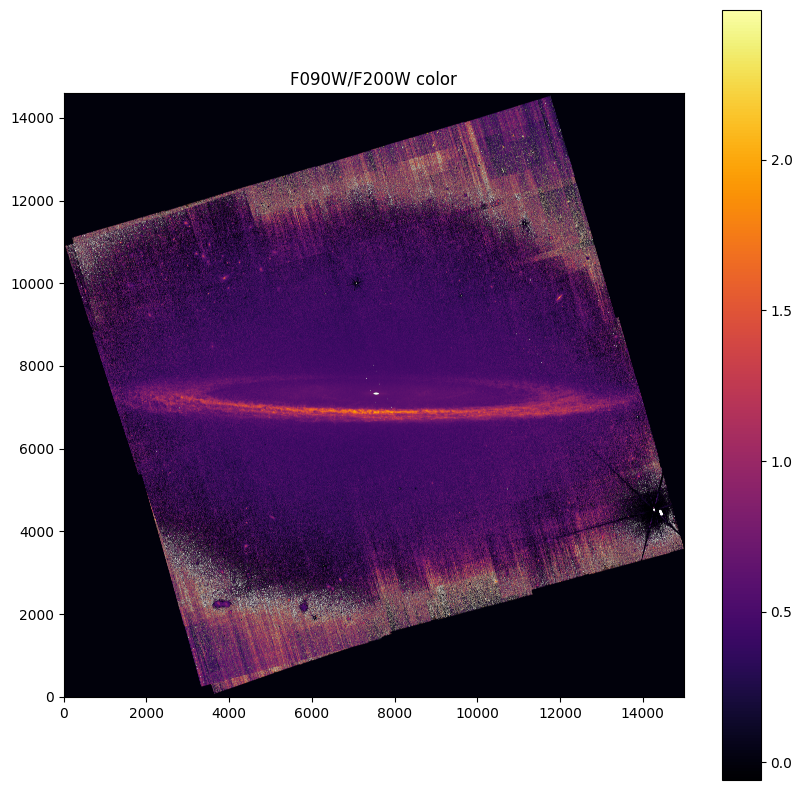

In [22]:
import numpy as np
from scipy.ndimage import gaussian_filter, label, distance_transform_edt

def fill_edge_nan_regions_with_zero(data, connectivity=8):
    """
    Set NaN regions connected to the image edge to 0.
    Leave interior NaN regions untouched.
    """
    out = np.array(data, dtype=float, copy=True)

    nan_mask = np.isnan(out)

    if connectivity == 8:
        structure = np.ones((3, 3), dtype=bool)
    elif connectivity == 4:
        structure = np.array([[0, 1, 0],
                              [1, 1, 1],
                              [0, 1, 0]], dtype=bool)
    else:
        raise ValueError("connectivity must be 4 or 8")

    labels, nlabels = label(nan_mask, structure=structure)

    if nlabels == 0:
        return out

    # Labels that touch any image edge
    edge_labels = np.unique(
        np.concatenate([
            labels[0, :],
            labels[-1, :],
            labels[:, 0],
            labels[:, -1],
        ])
    )

    # Remove background label 0
    edge_labels = edge_labels[edge_labels != 0]

    edge_nan_mask = np.isin(labels, edge_labels)

    # Fill only edge-connected NaN regions
    out[edge_nan_mask] = 0.0

    return out

edge_filled_data = fill_edge_nan_regions_with_zero(dmag[1].data, connectivity=8)

fig, ax = plt.subplots(figsize=(10, 10))
cb = ax.imshow(edge_filled_data, origin="lower", cmap="inferno",
            vmin=np.nanpercentile(edge_filled_data, 5), vmax=np.nanpercentile(edge_filled_data, 99.5))
plt.colorbar(cb, ax=ax)
ax.set_title("F090W/F200W color")
plt.show()


# Fix NaNs

In [23]:
def fix_remaining_nans_nearest(data):
    """
    Fill remaining NaNs using nearest valid pixel.
    Much faster than scipy.interpolate.griddata(..., method='nearest')
    for image-like arrays.
    """
    out = np.array(data, dtype=float, copy=True)

    nan_mask = np.isnan(out)

    if not np.any(nan_mask):
        return out

    valid_mask = ~nan_mask

    if not np.any(valid_mask):
        raise ValueError("Image contains only NaNs after edge filling.")

    # For each NaN pixel, find index of nearest valid pixel
    nearest_indices = distance_transform_edt(
        nan_mask,
        return_distances=False,
        return_indices=True
    )

    out[nan_mask] = out[tuple(nearest_indices[:, nan_mask])]

    return out

data_all_fixed = fix_remaining_nans_nearest(edge_filled_data)

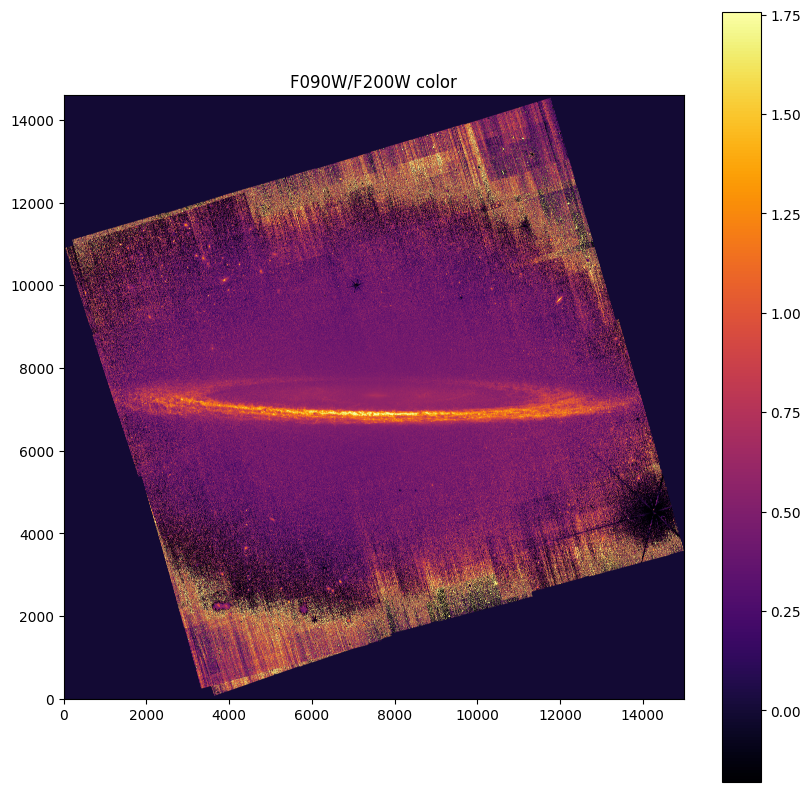

In [24]:
fig, ax = plt.subplots(figsize=(10, 10))
cb = ax.imshow(data_all_fixed, origin="lower", cmap="inferno",
            vmin=np.nanpercentile(data_all_fixed, 5), vmax=np.nanpercentile(data_all_fixed, 98))
plt.colorbar(cb, ax=ax)
ax.set_title("F090W/F200W color")
plt.show()

In [26]:
# now lets apply a 2 arcsecond smoothing to the dmag image and plot it again

from scipy.ndimage import gaussian_filter

# we need to transform the sigma from arcseconds to pixels
sigma_pixels = 1 / 0.031 # he pixel scale of JWST NIRCam is 0.031 arcseconds/pixel, so 2 arcseconds corresponds to 2/0.031 = 64.5 pixels


dmag_smooth = gaussian_filter(data_all_fixed, sigma=sigma_pixels)


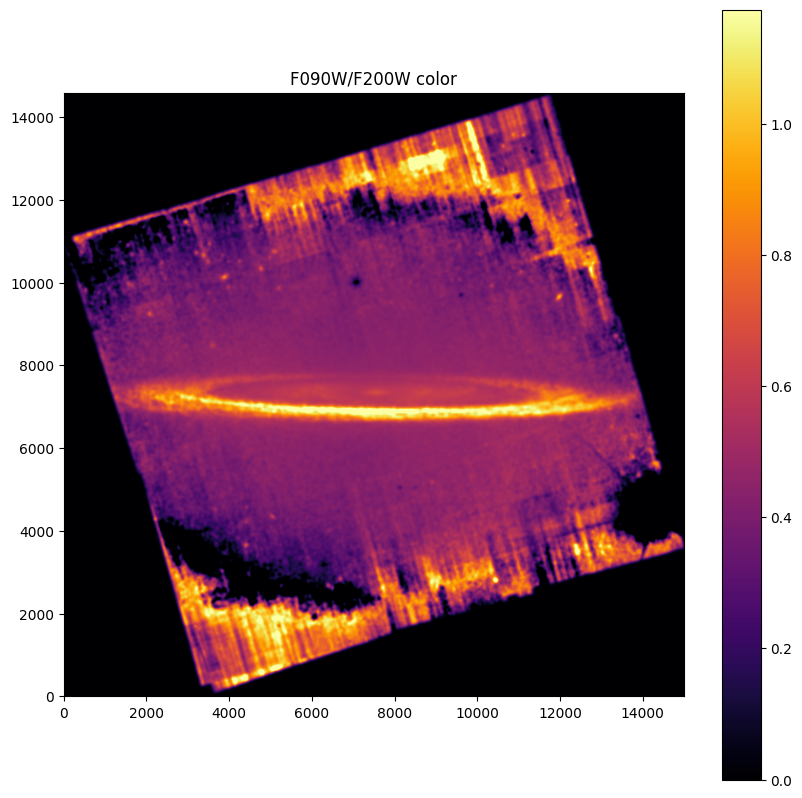

In [27]:
fig, ax = plt.subplots(figsize=(10, 10))
cb = ax.imshow(dmag_smooth, origin="lower", cmap="inferno",
            vmin=np.nanpercentile(dmag_smooth, 5), vmax=np.nanpercentile(dmag_smooth, 99.5))
plt.colorbar(cb, ax=ax)
ax.set_title("F090W/F200W color")
plt.show()


In [28]:
from astropy.wcs import WCS
from scipy.ndimage import distance_transform_edt, map_coordinates


def sample_dmag_over_ppxf_spaxels(
    muse_table,
    dmag_image,
    dmag_wcs,
    muse_wcs,
    row_col="ROW",
    column_col="COL",
    output_col="DMAG_MEAN",
    coverage_col="DMAG_VALID_FRAC",
    subpixels=9,
    batch_size=2048,
    fill_nan_nearest=True,
    crop_padding=64,
):
    """Average a high-resolution dmag image over every pPXF MUSE spaxel.

    The MUSE ROW/COL values are assumed to be FITS-style 1-based pixel
    indices. Each 0.2 arcsec MUSE pixel is sampled on a subpixels x
    subpixels grid, transformed through the MUSE and dmag celestial WCS,
    and averaged while ignoring non-finite dmag samples.

    Parameters
    ----------
    muse_table : astropy.table.Table or FITS table data
        Spaxel-level MUSE table containing ROW and COL columns.
    dmag_image : 2D array
        F090W-F200W colour image.
    dmag_wcs, muse_wcs : astropy.wcs.WCS
        Celestial WCS objects for the dmag image and original MUSE cube.
    subpixels : int
        Samples per MUSE-pixel axis. Nine is slightly finer than the
        approximately 0.031 arcsec dmag pixel scale.

    Returns
    -------
    astropy.table.Table
        Copy of the pPXF SPAXELS table with spaxel-level dmag columns.
    """
    output = Table(muse_table, copy=True)
    image = np.asarray(dmag_image)
    if image.ndim != 2:
        raise ValueError("dmag_image must be a 2D array")
    if subpixels < 1:
        raise ValueError("subpixels must be at least 1")

    # Keep only the two celestial axes if a full cube WCS was supplied.
    dmag_celestial = dmag_wcs.celestial
    muse_celestial = muse_wcs.celestial

    # Astropy WCS uses zero-based pixel centres, whereas ROW/COL are 1-based.
    muse_x = np.asarray(output[column_col], dtype=float) - 1.0
    muse_y = np.asarray(output[row_col], dtype=float) - 1.0

    # Work only on the part of the very large dmag mosaic that covers MUSE.
    footprint_x = np.array([
        np.min(muse_x) - 0.5, np.max(muse_x) + 0.5,
        np.max(muse_x) + 0.5, np.min(muse_x) - 0.5,
    ])
    footprint_y = np.array([
        np.min(muse_y) - 0.5, np.min(muse_y) - 0.5,
        np.max(muse_y) + 0.5, np.max(muse_y) + 0.5,
    ])
    footprint_sky = muse_celestial.pixel_to_world(footprint_x, footprint_y)
    footprint_dmag_x, footprint_dmag_y = dmag_celestial.world_to_pixel(
        footprint_sky
    )
    x0 = max(0, int(np.floor(np.min(footprint_dmag_x))) - crop_padding)
    x1 = min(image.shape[1], int(np.ceil(np.max(footprint_dmag_x))) + crop_padding + 1)
    y0 = max(0, int(np.floor(np.min(footprint_dmag_y))) - crop_padding)
    y1 = min(image.shape[0], int(np.ceil(np.max(footprint_dmag_y))) + crop_padding + 1)
    image_crop = np.array(image[y0:y1, x0:x1], dtype=float, copy=True)

    if fill_nan_nearest and np.any(~np.isfinite(image_crop)):
        invalid = ~np.isfinite(image_crop)
        if np.all(invalid):
            raise ValueError("The dmag crop covering MUSE contains no finite pixels")
        nearest = distance_transform_edt(
            invalid,
            return_distances=False,
            return_indices=True,
        )
        image_crop[invalid] = image_crop[tuple(nearest[:, invalid])]

    # Midpoints of equal-area subpixels spanning each MUSE pixel footprint.
    offsets = (np.arange(subpixels, dtype=float) + 0.5) / subpixels - 0.5
    offset_x, offset_y = np.meshgrid(offsets, offsets)
    offset_x = offset_x.ravel()
    offset_y = offset_y.ravel()
    samples_per_spaxel = offset_x.size

    mean_dmag = np.full(len(output), np.nan, dtype=float)
    valid_fraction = np.zeros(len(output), dtype=float)

    for start in range(0, len(output), batch_size):
        stop = min(start + batch_size, len(output))
        x_samples = muse_x[start:stop, None] + offset_x[None, :]
        y_samples = muse_y[start:stop, None] + offset_y[None, :]

        sky = muse_celestial.pixel_to_world(
            x_samples.ravel(), y_samples.ravel()
        )
        dmag_x, dmag_y = dmag_celestial.world_to_pixel(sky)

        sampled = map_coordinates(
            image_crop,
            [dmag_y - y0, dmag_x - x0],
            order=1,
            mode="constant",
            cval=np.nan,
            prefilter=False,
        ).reshape(stop - start, samples_per_spaxel)

        finite = np.isfinite(sampled)
        n_finite = finite.sum(axis=1)
        valid_fraction[start:stop] = n_finite / samples_per_spaxel
        np.divide(
            np.nansum(sampled, axis=1),
            n_finite,
            out=mean_dmag[start:stop],
            where=n_finite > 0,
        )

    output[output_col] = mean_dmag
    output[coverage_col] = valid_fraction
    return output


def add_mean_dmag_to_binned_kinematics(
    bin_results,
    spaxels,
    dmag_image,
    dmag_wcs,
    muse_wcs,
    bin_id_col="BIN_ID",
    output_col="DMAG_MEAN",
    coverage_col="DMAG_VALID_FRAC",
    subpixels=9,
    batch_size=2048,
    fill_nan_nearest=True,
    crop_padding=64,
):
    """Attach one footprint-averaged dmag value to each pPXF bin.

    Dust values are first measured over the footprint of every spaxel in
    the pPXF SPAXELS table. They are then combined using BIN_ID, so the
    returned table has exactly one row per BIN_RESULTS kinematic bin.
    """
    bins = Table(bin_results, copy=True)
    sampled_spaxels = sample_dmag_over_ppxf_spaxels(
        spaxels,
        dmag_image,
        dmag_wcs,
        muse_wcs,
        output_col=output_col,
        coverage_col=coverage_col,
        subpixels=subpixels,
        batch_size=batch_size,
        fill_nan_nearest=fill_nan_nearest,
        crop_padding=crop_padding,
    )

    spaxel_bin_ids = np.asarray(sampled_spaxels[bin_id_col], dtype=int)
    spaxel_dmag = np.asarray(sampled_spaxels[output_col], dtype=float)
    spaxel_coverage = np.asarray(sampled_spaxels[coverage_col], dtype=float)

    bin_mean = np.full(len(bins), np.nan, dtype=float)
    bin_coverage = np.zeros(len(bins), dtype=float)
    n_spaxels = np.zeros(len(bins), dtype=int)

    for index, bin_id in enumerate(np.asarray(bins[bin_id_col], dtype=int)):
        members = spaxel_bin_ids == bin_id
        n_spaxels[index] = np.count_nonzero(members)
        if n_spaxels[index] == 0:
            continue

        coverage = spaxel_coverage[members]
        values = spaxel_dmag[members]
        usable = np.isfinite(values) & (coverage > 0)

        # Coverage is proportional to the number of valid subpixel samples,
        # so this is the mean over all valid dmag samples in the whole bin.
        if np.any(usable):
            bin_mean[index] = np.average(values[usable], weights=coverage[usable])
        bin_coverage[index] = np.mean(coverage)

    bins[output_col] = bin_mean
    bins[coverage_col] = bin_coverage
    bins["N_DMAG_SPAX"] = n_spaxels
    return bins


def inflate_dusty_kinematic_uncertainties(
    binned_kinematics,
    dmag_threshold=1.2,
    sigma_inflate=1e6,
    dmag_col="DMAG_MEAN",
    uncertainty_cols=("VERR_KMS", "SIGERR_KMS", "H3_ERR", "H4_ERR"),
):
    """Set all kinematic errors to sigma_inflate in dusty pPXF bins."""
    masked = Table(binned_kinematics, copy=True)
    dmag_values = np.asarray(masked[dmag_col], dtype=float)
    dust_mask = np.isfinite(dmag_values) & (dmag_values > dmag_threshold)

    missing = [column for column in uncertainty_cols if column not in masked.colnames]
    if missing:
        raise KeyError(f"Missing kinematic uncertainty columns: {missing}")

    for column in uncertainty_cols:
        masked[column][dust_mask] = float(sigma_inflate)

    masked["DUST_MASKED"] = dust_mask
    masked.meta["DMAGTHR"] = float(dmag_threshold)
    masked.meta["ERRINFL"] = float(sigma_inflate)
    return masked


def save_dust_masked_ppxf_product(
    input_hdul,
    masked_bin_results,
    output_path,
    overwrite=True,
):
    """Save a complete pPXF FITS product with dust-masked bin errors.

    BIN_RESULTS is replaced by masked_bin_results. The replicated kinematic
    errors in SPAXELS are synchronized by BIN_ID for internal consistency.
    """
    from pathlib import Path

    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    output_hdul = fits.HDUList([hdu.copy() for hdu in input_hdul])
    masked_bins = Table(masked_bin_results, copy=True)

    output_hdul["BIN_RESULTS"] = fits.BinTableHDU(
        masked_bins, name="BIN_RESULTS"
    )

    if "SPAXELS" in output_hdul:
        output_spaxels = Table(output_hdul["SPAXELS"].data, copy=True)
        bin_ids = np.asarray(masked_bins["BIN_ID"], dtype=int)
        row_for_bin = {bin_id: row for row, bin_id in enumerate(bin_ids)}
        spaxel_bin_ids = np.asarray(output_spaxels["BIN_ID"], dtype=int)
        bin_rows = np.array([row_for_bin[bin_id] for bin_id in spaxel_bin_ids])

        columns_to_sync = [
            "VERR_KMS", "SIGERR_KMS", "H3_ERR", "H4_ERR",
            "DMAG_MEAN", "DMAG_VALID_FRAC", "DUST_MASKED",
        ]
        for column in columns_to_sync:
            if column in masked_bins.colnames:
                output_spaxels[column] = np.asarray(masked_bins[column])[bin_rows]

        output_hdul["SPAXELS"] = fits.BinTableHDU(
            output_spaxels, name="SPAXELS"
        )

    dust_mask = np.asarray(masked_bins["DUST_MASKED"], dtype=bool)
    output_hdul[0].header["DUSTMSK"] = (True, "Dust-masked kinematic errors")
    output_hdul[0].header["DMAGTHR"] = (
        float(masked_bins.meta["DMAGTHR"]), "Dust threshold"
    )
    output_hdul[0].header["ERRINFL"] = (
        float(masked_bins.meta["ERRINFL"]), "Masked-bin error value"
    )
    output_hdul[0].header["NDUSTBIN"] = (
        int(np.count_nonzero(dust_mask)), "Number of dust-masked bins"
    )

    output_hdul.writeto(output_path, overwrite=overwrite)
    output_hdul.close()
    return output_path


In [29]:
# Use the original MUSE cube WCS because the pPXF product stores ROW/COL,
# but does not retain a celestial WCS in its SPAXELS extension.
muse_cube_path = (
    "/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/"
    "Data/MUSE/c30_cubes/c30_DATACUBE_normppxf_skycont_Part1_0000.fits"
)

with fits.open(muse_cube_path) as muse_cube:
    muse_wcs = WCS(muse_cube["DATA"].header).celestial

dmag_wcs = WCS(dmag[1].header).celestial
muse_bin_results = Table(muse_emiles["BIN_RESULTS"].data)
muse_spaxels = Table(muse_emiles["SPAXELS"].data)

# The loaded dmag image is cropped to the MUSE footprint internally. NaNs
# in that small crop are filled from the nearest finite dmag pixel, matching
# the intended treatment above without copying the full 1.6 GB mosaic.
muse_bins_with_dmag = add_mean_dmag_to_binned_kinematics(
    muse_bin_results,
    muse_spaxels,
    dmag[1].data,
    dmag_wcs,
    muse_wcs,
    subpixels=9,
)

muse_bins_with_dmag[
    ["BIN_ID", "X_ARCSEC", "Y_ARCSEC", "N_SPAX", "DMAG_MEAN", "DMAG_VALID_FRAC"]
][:10]


BIN_ID,X_ARCSEC,Y_ARCSEC,N_SPAX,DMAG_MEAN,DMAG_VALID_FRAC
int32,float64,float64,int32,float64,float64
0,0.1000000000000008,0.0,2,0.6890904580280193,1.0
1,-0.8000000000000064,-0.1000000000000008,2,0.6803314983627544,1.0
2,-0.8666666666666737,0.5333333333333375,3,0.6915036837655997,1.0
3,-0.2000000000000016,-0.1000000000000008,2,0.689880764765041,1.0
4,0.0,0.500000000000004,2,0.6903879437981734,1.0
5,-0.2000000000000016,0.500000000000004,2,0.6767770202870209,1.0
6,0.4000000000000032,0.3000000000000024,2,0.6931750380337494,1.0
7,0.500000000000004,0.0,2,0.6922047383853906,1.0
8,0.4000000000000032,-0.3000000000000024,2,0.6726151522810324,1.0


In [40]:
# Bins redder than the threshold receive negligible weight in dynamical fits.
DMAG_THRESHOLD = 0.8
SIGMA_INFLATE = 1e6

muse_bins_dust_masked = inflate_dusty_kinematic_uncertainties(
    muse_bins_with_dmag,
    dmag_threshold=DMAG_THRESHOLD,
    sigma_inflate=SIGMA_INFLATE,
)

print(
    f"Dust-masked {np.count_nonzero(muse_bins_dust_masked['DUST_MASKED'])} "
    f"of {len(muse_bins_dust_masked)} pPXF kinematic bins."
)

muse_bins_dust_masked[
    ["BIN_ID", "DMAG_MEAN", "DUST_MASKED", "VERR_KMS", "SIGERR_KMS", "H3_ERR", "H4_ERR"]
][muse_bins_dust_masked["DUST_MASKED"]][:10]


Dust-masked 65 of 2180 pPXF kinematic bins.


BIN_ID,DMAG_MEAN,DUST_MASKED,VERR_KMS,SIGERR_KMS,H3_ERR,H4_ERR
int32,float64,bool,float64,float64,float64,float64
1480,0.8270182252952071,True,1000000.0,1000000.0,1000000.0,1000000.0
1513,0.8368543199783587,True,1000000.0,1000000.0,1000000.0,1000000.0
1541,0.8120966565027986,True,1000000.0,1000000.0,1000000.0,1000000.0
1551,1.2083250806335184,True,1000000.0,1000000.0,1000000.0,1000000.0
1581,0.8251572597979914,True,1000000.0,1000000.0,1000000.0,1000000.0
1604,1.041914227459216,True,1000000.0,1000000.0,1000000.0,1000000.0
1630,1.0389825603655205,True,1000000.0,1000000.0,1000000.0,1000000.0
1656,0.9873515951285563,True,1000000.0,1000000.0,1000000.0,1000000.0
1674,0.8153428807720341,True,1000000.0,1000000.0,1000000.0,1000000.0


In [41]:
masked_output_path = (
    "/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/"
    "Data/ppxf_muse/emiles_ppxf_muse/"
    "c30_DATACUBE_normppxf_skycont_Part1_0000_ppxf_products_emiles_dustmasked.fits"
)

saved_masked_path = save_dust_masked_ppxf_product(
    muse_emiles,
    muse_bins_dust_masked,
    masked_output_path,
    overwrite=True,
)
print(f"Saved dust-masked pPXF product to {saved_masked_path}")


Saved dust-masked pPXF product to /Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/ppxf_muse/emiles_ppxf_muse/c30_DATACUBE_normppxf_skycont_Part1_0000_ppxf_products_emiles_dustmasked.fits


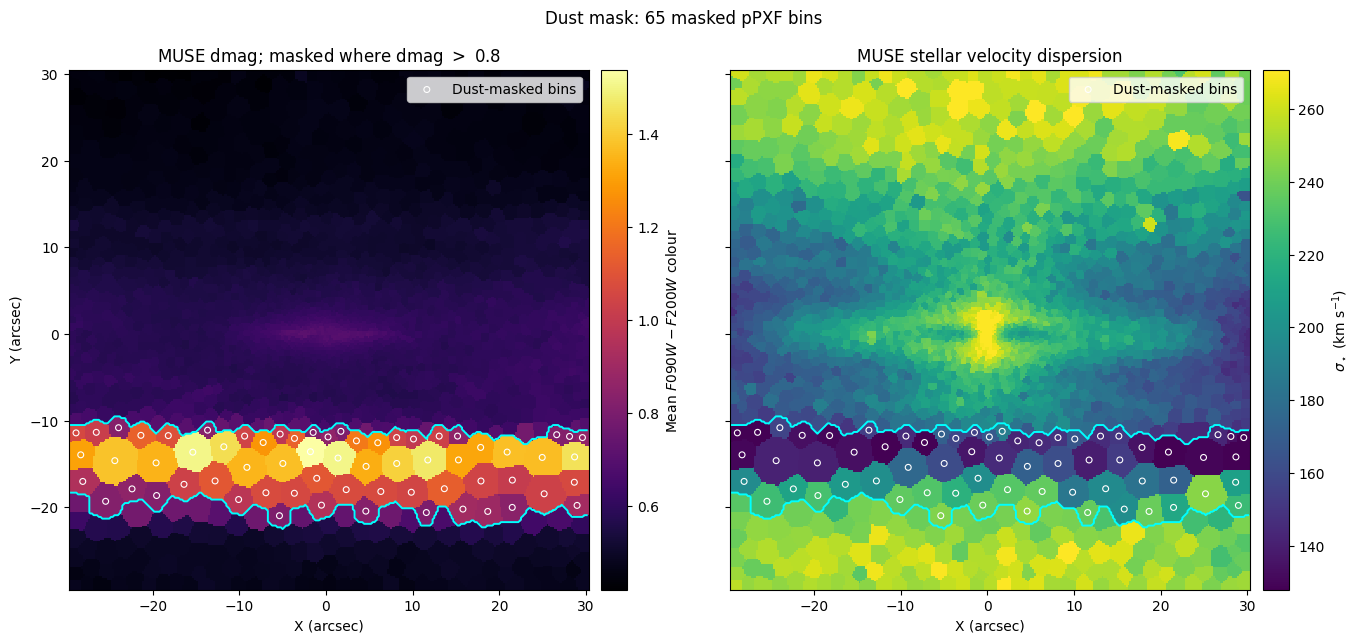

In [42]:
def plot_muse_dust_mask_diagnostics(binned_kinematics, spaxels):
    """Plot binned dmag and sigma maps with dust-masked bins outlined."""
    bins = Table(binned_kinematics, copy=False)
    spaxels = Table(spaxels, copy=False)

    bin_ids = np.asarray(bins["BIN_ID"], dtype=int)
    row_for_bin = {bin_id: row for row, bin_id in enumerate(bin_ids)}
    spaxel_bin_ids = np.asarray(spaxels["BIN_ID"], dtype=int)
    bin_rows = np.array([row_for_bin[bin_id] for bin_id in spaxel_bin_ids])

    rows = np.asarray(spaxels["ROW"], dtype=int) - 1
    columns = np.asarray(spaxels["COL"], dtype=int) - 1
    ny = rows.max() + 1
    nx = columns.max() + 1

    dmag_map = np.full((ny, nx), np.nan)
    sigma_map = np.full((ny, nx), np.nan)
    masked_map = np.zeros((ny, nx), dtype=bool)
    dmag_map[rows, columns] = np.asarray(bins["DMAG_MEAN"], dtype=float)[bin_rows]
    sigma_map[rows, columns] = np.asarray(bins["SIGMA_KMS"], dtype=float)[bin_rows]
    masked_map[rows, columns] = np.asarray(bins["DUST_MASKED"], dtype=bool)[bin_rows]

    pixel_size = float(muse_emiles[0].header.get("PIXSIZE", 0.2))
    extent = (
        np.min(spaxels["X_ARCSEC"]) - pixel_size / 2,
        np.max(spaxels["X_ARCSEC"]) + pixel_size / 2,
        np.min(spaxels["Y_ARCSEC"]) - pixel_size / 2,
        np.max(spaxels["Y_ARCSEC"]) + pixel_size / 2,
    )

    finite_sigma = sigma_map[np.isfinite(sigma_map)]
    sigma_limits = np.nanpercentile(finite_sigma, [1, 99])

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)
    panels = [
        (dmag_map, "inferno", None, None, r"Mean $F090W-F200W$ colour", "dmag"),
        (
            sigma_map,
            "viridis",
            sigma_limits[0],
            sigma_limits[1],
            r"$\sigma_\star$ (km s$^{-1}$)",
            "sigma",
        ),
    ]

    for ax, (image, cmap, vmin, vmax, colorbar_label, title) in zip(axes, panels):
        shown = ax.imshow(
            image,
            origin="lower",
            extent=extent,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            interpolation="nearest",
            aspect="equal",
        )
        ax.contour(
            masked_map.astype(float),
            levels=[0.5],
            colors="cyan",
            linewidths=1.4,
            origin="lower",
            extent=extent,
        )
        ax.scatter(
            np.asarray(bins["X_ARCSEC"])[bins["DUST_MASKED"]],
            np.asarray(bins["Y_ARCSEC"])[bins["DUST_MASKED"]],
            s=18,
            facecolors="none",
            edgecolors="white",
            linewidths=0.8,
            label="Dust-masked bins",
        )
        fig.colorbar(shown, ax=ax, pad=0.02, label=colorbar_label)
        ax.set_title(title)
        ax.set_xlabel("X (arcsec)")
        ax.legend(loc="upper right", frameon=True)

    axes[0].set_ylabel("Y (arcsec)")
    axes[0].set_title(
        rf"MUSE dmag; masked where dmag $>$ {DMAG_THRESHOLD:g}"
    )
    axes[1].set_title(r"MUSE stellar velocity dispersion")
    fig.suptitle(
        f"Dust mask: {np.count_nonzero(bins['DUST_MASKED'])} masked pPXF bins",
        y=1.02,
    )
    fig.tight_layout()
    return fig, axes


fig_dust_diagnostic, axes_dust_diagnostic = plot_muse_dust_mask_diagnostics(
    muse_bins_dust_masked,
    muse_spaxels,
)
plt.show()


In [44]:
muse_bins_dust_masked

BIN_ID,X_ARCSEC,Y_ARCSEC,V_KMS,SIGMA_KMS,H3,H4,VERR_KMS,SIGERR_KMS,H3_ERR,H4_ERR,LOGAGE_YR,MEAN_METAL,LOGAGE_ERR,METAL_ERR,REGUL,N_SPAX,SN_BIN,CHI2,DMAG_MEAN,DMAG_VALID_FRAC,N_DMAG_SPAX,DUST_MASKED
int32,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int32,float64,float64,float64,float64,int64,bool
0,0.1000000000000008,0.0,-58.69150440146978,303.7454452227789,0.0044990742075008815,0.11281308265493625,3.544992077268052,4.606154652245005,0.008791364786857724,0.01047953586339339,10.175071613065136,0.21996928062018883,nan,nan,45.35630438750997,2,78.22005664181327,1.0293367103723683,0.6890904580280193,1.0,2,False
1,-0.8000000000000064,-0.1000000000000008,103.5395520532997,277.0407515597923,-0.05104924177511204,0.11737321946244897,3.2074591354108732,4.161467579313996,0.008863138893320055,0.01066975306700161,10.173253518435315,0.21997295622734608,nan,nan,48.79630290577445,2,78.4975860801083,1.029286879347341,0.6803314983627544,1.0,2,False
2,-0.8666666666666737,0.5333333333333375,94.17970875997693,277.89250905099846,-0.05974379723597948,0.11938019846929933,3.0161185598321456,3.8974678654912474,0.00825955110020469,0.009988173631886702,10.173599918861084,0.21923338392238914,nan,nan,49.59550412125548,3,81.0768259489264,1.0294363984445252,0.6915036837655997,1.0,3,False
3,-0.2000000000000016,-0.1000000000000008,0.963370271479719,296.48942438272815,-0.026542366568895425,0.1203116274191941,3.6687001339239136,4.773803848766851,0.00935538281465795,0.011220160049872165,10.174327842110452,0.2191125754161921,nan,nan,46.34947812708464,2,74.05203768312529,1.0292656707095866,0.689880764765041,1.0,2,False
4,0.0,0.500000000000004,-32.07803510474344,302.05045983947963,-0.0005375270860510277,0.10735115314411879,3.3556669268005472,4.2779134679163455,0.008378675517569371,0.009978797889554778,10.173334446387514,0.22,nan,nan,49.19428058082939,2,76.57441818443188,1.0292918679252197,0.6903879437981734,1.0,2,False
5,-0.2000000000000016,0.500000000000004,3.979087831632719,298.0745926853691,-0.03184696118621691,0.10394797493105803,3.435760732922371,4.325925154058634,0.008663484197832451,0.01031363409670553,10.174765245319085,0.2199325601149891,nan,nan,45.974514669397344,2,77.7190453175265,1.0293376844242104,0.6767770202870209,1.0,2,False
6,0.4000000000000032,0.3000000000000024,-91.88044425633299,292.03155657558796,0.034018221237156705,0.11709310897997206,3.1572084963305334,4.1457767817520645,0.0082925564651796,0.009997321308206372,10.17342442317899,0.2197389277536061,nan,nan,49.32765980638086,2,78.87618488255151,1.0292629952504875,0.6931750380337494,1.0,2,False
7,0.500000000000004,0.0,-113.51260525231874,275.40279044431844,0.038993973730705685,0.11831328900593281,3.112635019068909,4.026918492004388,0.008615344620834554,0.010380090243285631,10.17311317419783,0.21943588626418112,nan,nan,50.47608334839724,2,77.41058488371655,1.0293370400905961,0.6922047383853906,1.0,2,False
8,0.4000000000000032,-0.3000000000000024,-93.00647095892239,283.4299847108258,0.038573259617137,0.12439615636098683,3.179609095649953,4.134877357211278,0.008532770932582444,0.010333979582926279,10.174930440201257,0.21941554555153475,nan,nan,47.10860447580836,2,79.39689995504229,1.0292325252999808,0.6726151522810324,1.0,2,False


In [47]:
# Prepare a standalone DYNAMITE input directory from the dust-masked pPXF product.
from pathlib import Path
import sys

workspace_root = Path("/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL")
dynamite_code_dir = workspace_root / "dynamite"
if str(dynamite_code_dir) not in sys.path:
    sys.path.insert(0, str(dynamite_code_dir))

from generate_kin_input import (
    create_sombrero_mge_input,
    create_sombrero_muse_kin_input,
)

dynamite_masked_input_dir = dynamite_code_dir / "dynamite_input_muse_dustmasked"
mge_source_path = (
    workspace_root
    / "Data/mge_NAGN_0deg_pa_positive_gauss/mge_luminosity_table.csv"
)

dynamite_masked_outputs = {
    "mge": create_sombrero_mge_input(
        mge_source_path,
        dynamite_masked_input_dir,
        output_name="mge.ecsv",
        pa_twist=0.0,
        distance_mpc=9.55,
    ),
    "muse": create_sombrero_muse_kin_input(
        saved_masked_path,
        dynamite_masked_input_dir,
        expr="",
        angle_deg=0.0,
        angle_is_aperture_angle=True,
        n_gh=4,
        psf_sigma=1.5,
        psf_weight=1.0,
        fit_PA=False,
        plot=False,
    ),
}

dynamite_masked_outputs


{'mge': PosixPath('/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/dynamite/dynamite_input_muse_dustmasked/mge.ecsv'),
 'muse': {'aperture': PosixPath('/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/dynamite/dynamite_input_muse_dustmasked/aperture.dat'),
  'bins': PosixPath('/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/dynamite/dynamite_input_muse_dustmasked/bins.dat'),
  'kinematics': PosixPath('/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/dynamite/dynamite_input_muse_dustmasked/gauss_hermite_kins.ecsv'),
  'n_bins': 2180,
  'n_pixels': 90000,
  'pixel_size': 0.1999999999999993,
  'grid_shape': (300, 300)}}